In [2]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
import pandas as pd
import scipy.stats as st


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

from sbin.complexity import gap_complexity
from sbin.plotting_utilities import ecdf_confidence
import seaborn as sns 

from scipy.stats import ks_2samp

from sbin.suppression_utilities import suppression_factor_simple
from sbin.suppression_utilities import suppression_factor_mk21
from sbin.suppression_utilities import suppression_factor_snow, a_to_snow 





In [3]:
with open("filtered_data.pkl", "rb") as f:
    data = pickle.load(f)
    db_filtered = data["binaries_filtered"]
    kois_filtered_cc = data[ "kois_filtered_cc"]

close_bin = data['binaries_filtered'].loc[data['binaries_filtered']['SepAU'] < 100]

KS statistic: 0.159, p-value: 0.344


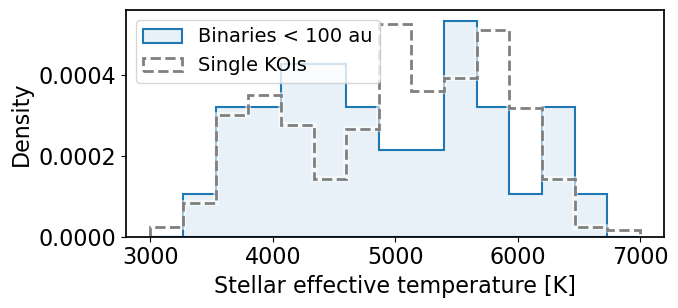

In [4]:
nbins = 15
histrange = (3000,7000)
fig, axes = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

# One temperature per KOI for binaries
close_bin_temps = close_bin.groupby('KOI')['steff_adopt'].first()

plt.hist(close_bin_temps, label='Binaries < 100 au',
             range=histrange, bins=nbins, density=True, 
             histtype='stepfilled', lw=1.5,
             edgecolor='#1f77b4', facecolor='#e8f1f7')

temps = kois_filtered_cc.groupby('KOI')['teff'].first()
plt.hist(temps, 
             range=histrange, bins=nbins, density=True, 
                histtype='step',lw=4, color='white', alpha=0.6)
plt.hist(temps, 
             range=histrange, bins=nbins, density=True, 
             histtype='step', lw=2, linestyle='--', color='gray',
            label='Single KOIs')


plt.ylabel('Density')
plt.xlabel('Stellar effective temperature [K]')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('plots/teff.png')


# Perform KS test between binary and single KOI temperatures
ks_stat, p_value = ks_2samp(close_bin_temps, temps)
print(f"KS statistic: {ks_stat:.3f}, p-value: {p_value:.3f}")

KS statistic: 0.121, p-value: 0.679


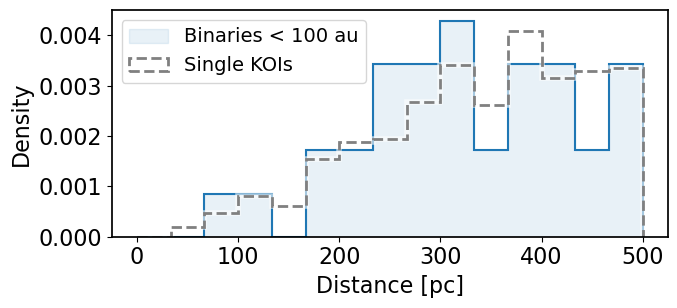

In [5]:
nbins = 15
histrange = (0,500)
fig, axes = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

# One distance per KOI for binaries
db_distances = close_bin.groupby('KOI')['distance'].first()

plt.hist(db_distances, label='Binaries < 100 au',
             range=histrange, bins=nbins, density=True, 
             histtype='stepfilled',  edgecolor='C0', facecolor='C0', alpha=0.1)

plt.hist(db_distances, 
             range=histrange, bins=nbins, density=True, 
             histtype='step', lw=1.5, edgecolor='C0')

k_distances = 1000./(kois_filtered_cc.groupby('kepid')['parallax'].first())
plt.hist(k_distances, 
             range=histrange, bins=nbins, density=True, 
                histtype='step',lw=4, color='white', alpha=0.6)
plt.hist(k_distances, 
             range=histrange, bins=nbins, density=True, 
             histtype='step', lw=2, linestyle='--', color='gray',
            label='Single KOIs')


plt.ylabel('Density')
plt.xlabel('Distance [pc]')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('plots/dist.png')

# Perform KS test between binary and single KOI temperatures
ks_stat, p_value = ks_2samp(db_distances, k_distances)
print(f"KS statistic: {ks_stat:.3f}, p-value: {p_value:.3f}")

KS statistic: 0.064, p-value: 0.970


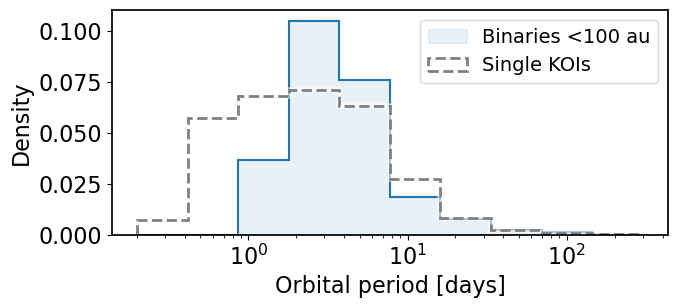

In [6]:
histrange = (0.2, 300)
nbins = 10
bin_edges = np.logspace(np.log10(histrange[0]), np.log10(histrange[1]), nbins + 1)
 
fig, axes = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

plt.hist(close_bin['koi_period'], label='Binaries <100 au',
             bins=bin_edges, density=True, 
             histtype='stepfilled',  edgecolor='C0', facecolor='C0', alpha=0.1)

plt.hist(close_bin['koi_period'], 
             bins=bin_edges, density=True, 
             histtype='step', lw=1.5, edgecolor='C0')

plt.hist(kois_filtered_cc['koi_period'], 
             bins=bin_edges, density=True, 
                histtype='step',lw=4, color='white', alpha=0.6)
plt.hist(kois_filtered_cc['koi_period'], 
             bins=bin_edges, density=True, 
             histtype='step', lw=2, linestyle='--', color='gray',
            label='Single KOIs')


plt.ylabel('Density')
plt.xlabel('Orbital period [days]')
plt.legend(loc='upper right')
plt.xscale('log')

plt.tight_layout()

plt.savefig('plots/plperiod.png')

# Perform KS test between binary and single KOI temperatures
ks_stat, p_value = ks_2samp(close_bin['koi_period'], kois_filtered_cc['koi_period'])
print(f"KS statistic: {ks_stat:.3f}, p-value: {p_value:.3f}")

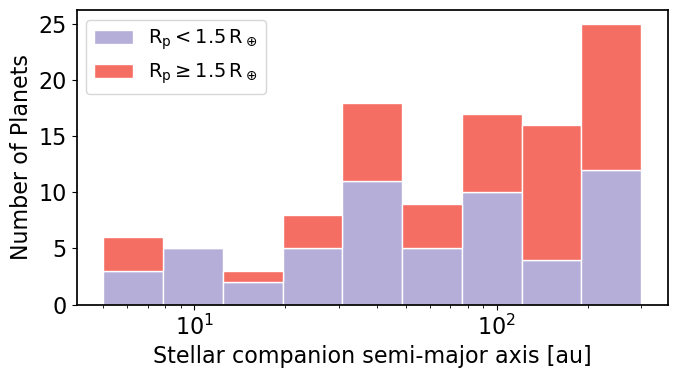

In [8]:
# Stacked histogram of binary semi-major axes separated by planet radius
small_planets = db_filtered[db_filtered['prad_adopt'] < 1.5]
large_planets = db_filtered[db_filtered['prad_adopt'] >= 1.5]

bins = np.logspace(np.log10(5), np.log10(300), 10)

fig, ax = plt.subplots(1, 1, figsize=(7,4))

plt.hist([small_planets['SepAU'], large_planets['SepAU']], bins=bins, 
         histtype='barstacked', 
         color=['#b4aed9', '#f56e63'], 
         alpha=1, edgecolor='white',
         label=['$R_p < 1.5 \, R_\oplus$', '$R_p \geq 1.5 \, R_\oplus$'])

plt.xscale('log')
plt.xlabel('Stellar companion semi-major axis [au]')
plt.ylabel('Number of Planets')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('plots/sep_stacked.png')



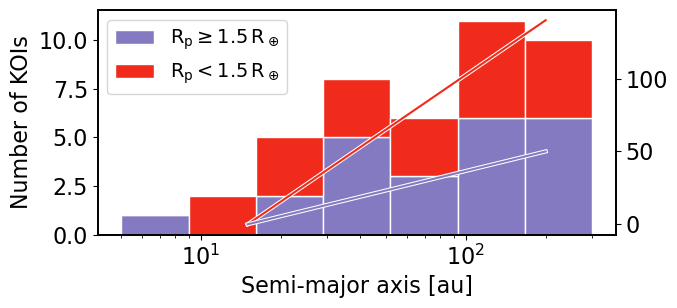

In [113]:
# Stacked histogram of binary semi-major axes for the largest planet per KOI
largest_per_koi = db_filtered.loc[db_filtered.groupby('KOI')['prad_adopt'].idxmax()]

small_planets = largest_per_koi[(largest_per_koi['prad_adopt'] < 1.5) &\
                                 (largest_per_koi['steff_adopt'] > 4500) &\
                                 (largest_per_koi['steff_adopt'] < 6500)]
large_planets = largest_per_koi[(largest_per_koi['prad_adopt'] >= 1.5) &\
                                 (largest_per_koi['steff_adopt'] > 4500) &\
                                 (largest_per_koi['steff_adopt'] < 6500)]

bins = np.logspace(np.log10(5), np.log10(300), 8)

fig, ax = plt.subplots(1, 1, figsize=(7,3.3))

plt.hist([large_planets['SepAU'], small_planets['SepAU']], bins=bins, 
         histtype='barstacked', 
         color=['#847ac1', '#f02b1b'], 
         alpha=1, edgecolor='white',
         label=['$R_p \geq 1.5 \, R_\oplus$', '$R_p < 1.5 \, R_\oplus$'])

plt.xscale('log')
plt.xlabel('Semi-major axis [au]')
plt.ylabel('Number of KOIs')
plt.legend(loc='upper left')

ax2 = ax.twinx()
ax2.set_xscale('log')
ax2.plot([15, 200], [0, 140], color='white', linestyle='-', linewidth=3)
ax2.plot([15, 200], [0, 140], color='#f02b1b', linestyle='-', linewidth=1.5)
ax2.plot([15, 200], [0, 50], color='white', linestyle='-', linewidth=3)
ax2.plot([15, 200], [0, 50], color='#847ac1', linestyle='-', linewidth=1.5)
ax2.tick_params(axis='x', colors='black')

plt.tight_layout()

plt.savefig('plots/sep_stacked_largest.png')

In [87]:
db_filtered['SepAU'].min()

5.56543234810507

KS statistic: 0.152, p-value: 0.147
KS statistic: 0.152, p-value: 0.147


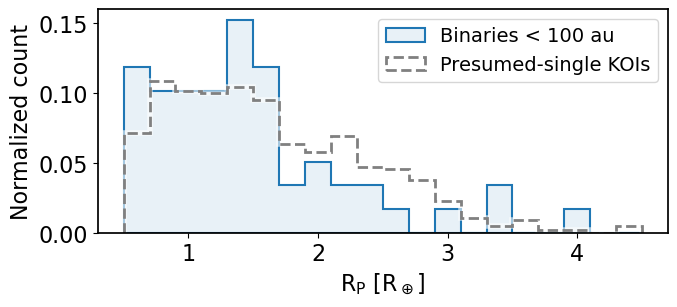

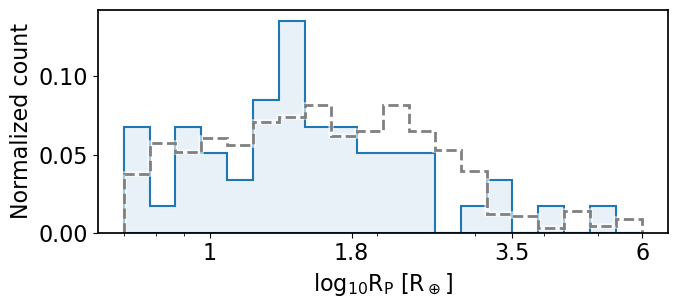

In [76]:

for option in ['linear','log']:

    nbins=20

    if option=='linear':
        histrange=[0.5,4.5]
        bin_edges = np.linspace(histrange[0], histrange[1], nbins + 1)
    else:
        histrange=[np.log10(0.7),np.log10(6)]
        bin_edges = np.logspace(histrange[0], histrange[1], nbins + 1)
        
    bin_width = np.diff(bin_edges)
    bin_center = bin_edges[:-1]+bin_width/2.
        
    fig, axes = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

    nplanets = len(db_filtered['prad_adopt'][db_filtered['SepAU']<100])
    ww = 1./np.full(nplanets, nplanets, dtype=float)
    y, _, _ = plt.hist(db_filtered['prad_adopt'][db_filtered['SepAU']<100], 
                  bins=bin_edges, weights=ww,
             histtype='stepfilled', lw=1.5,
             edgecolor='#1f77b4', facecolor='#e8f1f7',
            label='Binaries < 100 au') 
    
    # compared to the kois that are at least not definite binaries with good radii and per<100 days
    nplanets = len(kois_filtered_cc)
    plt.hist(kois_filtered_cc['koi_prad'], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=4, alpha=0.6, color='white')
    plt.hist(kois_filtered_cc['koi_prad'], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=2, linestyle='--', color='gray',
            label='Presumed-single KOIs') 

    plt.ylabel('Normalized count')
    
    if option=='linear':
        plt.legend()
        plt.xlabel('$R_P$ [$R_\oplus$]')        
    else:
        plt.xlabel('$log_{10} R_P$ [$R_\oplus$]')  
        plt.xscale('log')
        
        custom_log_ticks = [1, 1.8, 3.5, 6]
        plt.gca().set_xticks(custom_log_ticks)
        plt.gca().set_xticklabels([str(t) for t in custom_log_ticks])
        
    plt.tight_layout()
    plt.savefig('prad-'+option+'.png')

    plt.xlim()
    
    
    # Perform KS test between binary and single KOI temperatures
    ks_stat, p_value = ks_2samp(db_filtered['prad_adopt'][db_filtered['SepAU']<100], kois_filtered_cc['koi_prad'])
    print(f"KS statistic: {ks_stat:.3f}, p-value: {p_value:.3f}")
    

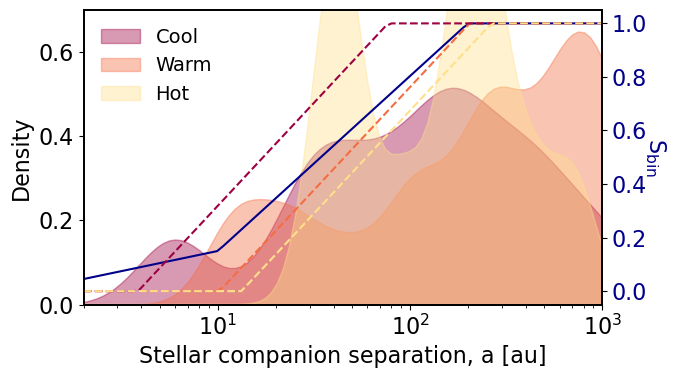

In [77]:
from scipy.stats import gaussian_kde

# ----------------------------------------------
# Set-up
# ----------------------------------------------

fig, ax1 = plt.subplots(figsize=(7, 4))

# defining the limits of the semi-major axis
a_values = np.logspace(-0.1,3, 100)
bins = np.logspace(np.log10(a_values.min()), np.log10(a_values.max()), 15)

# calculate suppression factors
S_values = suppression_factor_mk21(a_values)
S_values2 = suppression_factor_simple(a_values)


# ----------------------------------------------
# First axis -- histogram of planet radii
# ----------------------------------------------



# define the samples
cool = db_filtered['SepAU'][db_filtered['steff_adopt']<5000] # super-Earths
warm = db_filtered['SepAU'][(db_filtered['steff_adopt']>5000) & (db_filtered['steff_adopt']<5800)] # in-betweens
hot = db_filtered['SepAU'][db_filtered['steff_adopt']>5800] # mini-Neptunes

def calc_pdf(sample, a_values):
    kde = gaussian_kde(np.log10(sample), bw_method=0.2)
    pdf = kde(np.log10(a_values))
    return pdf

ax1.fill_between(a_values, calc_pdf(cool, a_values), color='#9e0142', alpha=0.4,
                 label='Cool')
ax1.fill_between(a_values, calc_pdf(warm, a_values), color='#f46d43', alpha=0.4,
                 label='Warm')
ax1.fill_between(a_values, calc_pdf(hot, a_values), color='#fee08b', alpha=0.4,
                 label='Hot')


ax1.set_xscale('log') # Set the x-axis to logarithmic scale
ax1.set_ylabel('Density', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax1.set_xlabel('Stellar companion separation, a [au]')
plt.legend(edgecolor='None', facecolor='w', loc='upper left')
plt.ylim(0,0.7)


# ----------------------------------------------
# Second axis -- the suppression equation
# ----------------------------------------------

ax2 = ax1.twinx()

ax2.plot(a_values, S_values, color='darkblue', linestyle='-', label='Suppression Factor')
ax2.plot(a_values, suppression_factor_snow(a_values, star_teff=5700.), 
         color='#f46d43', linestyle='--')
ax2.plot(a_values, suppression_factor_snow(a_values, star_teff=3500.), 
         color='#9e0142', linestyle='--')
ax2.plot(a_values, suppression_factor_snow(a_values, star_teff=6500.), 
         color='#fee08b', linestyle='--')
#S_values = suppression_factor_snow(a_values, 5800.)
#ax2.plot(a_values, S_values, color='green', linestyle='--', label='Suppression Factor')

ax2.tick_params(axis='y', labelcolor='darkblue')

ax2.set_ylabel('$S_\mathrm{bin}$', rotation=270, color='darkblue', labelpad=15)


# ----------------------------------------------
# Adjust and save
# ----------------------------------------------

plt.xscale('log')
plt.xlim(2,1000.)
plt.tight_layout()
plt.savefig('overview-semimajor.png')

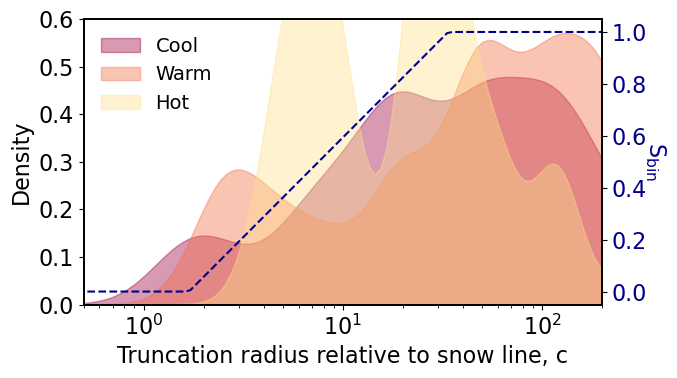

In [78]:
from scipy.stats import gaussian_kde

# ----------------------------------------------
# Set-up
# ----------------------------------------------

fig, ax1 = plt.subplots(figsize=(7, 4))

# defining the limits of the semi-major axis
a_values = np.logspace(-0.5,3.5, 150)
bins = np.logspace(np.log10(a_values.min()), np.log10(a_values.max()), 15)

# calculate suppression factors
S_values = suppression_factor_snow(a_values, star_teff=5800.)

# ----------------------------------------------
# First axis -- histogram of planet radii
# ----------------------------------------------

x = db_filtered['DiskAU']/db_filtered['SnowAU']
col = db_filtered['steff_adopt']

# define the samples
cool = x[col<5000] 
warm = x[(col>5000) & (col<5800)] 
hot = x[col>5800] 

ax1.fill_between(a_values, calc_pdf(cool, a_values), color='#9e0142', alpha=0.4,
                 label='Cool')
ax1.fill_between(a_values, calc_pdf(warm, a_values), color='#f46d43', alpha=0.4,
                 label='Warm')
ax1.fill_between(a_values, calc_pdf(hot, a_values), color='#fee08b', alpha=0.4,
                 label='Hot')


ax1.set_xscale('log') # Set the x-axis to logarithmic scale
ax1.set_ylabel('Density', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax1.set_xlabel('Truncation radius relative to snow line, c')
plt.legend(edgecolor='None', facecolor='w', loc='upper left')
plt.ylim(0,0.6)


# ----------------------------------------------
# Second axis -- the suppression equation
# ----------------------------------------------

ax2 = ax1.twinx()

ax2.plot(a_to_snow(a_values), S_values, color='darkblue', linestyle='--', label='Suppression Factor')
#ax2.plot(a_values, S_values2, color='darkblue', linestyle='--', label='Suppression Factor')
ax2.tick_params(axis='y', labelcolor='darkblue')

ax2.set_ylabel('$S_\mathrm{bin}$', rotation=270, color='darkblue', labelpad=15)


# ----------------------------------------------
# Adjust and save
# ----------------------------------------------

plt.xscale('log')
plt.xlim(0.5,200)
plt.tight_layout()
plt.savefig('overview-snow.png')

## Snow line conversaion calculation

0.17445095429923702 -0.6174456157301426


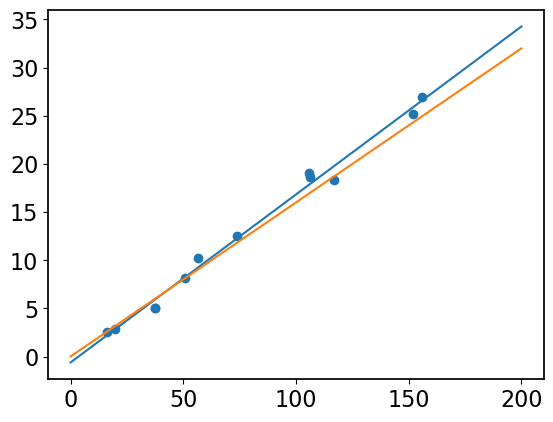

In [79]:
anchor = db_filtered.loc[(db_filtered['steff_adopt']>5500) & (db_filtered['steff_adopt']<6000) & (db_filtered['SepAU']<200.)]

x = anchor['SepAU']
y = anchor['DiskAU']/anchor['SnowAU']
plt.scatter(x,y)

x_fit = np.linspace(0,200, 100)
m_fit, b_fit = np.polyfit(x, y, 1)
print(m_fit, b_fit)

y_fit = b_fit + m_fit*x_fit
plt.plot(x_fit, y_fit)

a_to_snow = np.poly1d([0.16, 0.])
y_fit = a_to_snow(x_fit)
plt.plot(x_fit, y_fit)
